In [1]:
from google.colab import files
uploaded = files.upload()

Saving birlesik_tablo.csv to birlesik_tablo.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
veri = pd.read_csv('birlesik_tablo.csv')
print(veri.shape)
veri.head()

(1190, 14)


,ISO3,Ulke,Yil,Avg_Temp,Avg_Precip,Afet_Sayisi,Kuraklik_Sayisi,Sel_Sayisi,Firtina_Sayisi,Asiri_Sicaklik_Sayisi,Toplam_Olum,Toplam_Etkilenen,Toplam_Hasar_1000USD,Goc
0,AGO,Angola,2001,21.84,1043.69,2,1,1,0,0,106,39928,0,480464
1,AGO,Angola,2002,21.95,1076.96,0,0,0,0,0,0,0,0,449687
2,AGO,Angola,2003,22.01,1022.52,2,0,2,0,0,15,825,0,341284
3,AGO,Angola,2004,21.78,1059.90,4,1,3,0,0,28,358700,0,238382
4,AGO,Angola,2005,22.14,1011.95,1,0,1,0,0,0,10000,0,224147


In [5]:
veri['log_Goc'] = np.log1p(veri['Goc'])
veri['log_Toplam_Etkilenen'] = np.log1p(veri['Toplam_Etkilenen'])
veri['log_Toplam_Hasar'] = np.log1p(veri['Toplam_Hasar_1000USD'])
veri['log_Toplam_Olum'] = np.log1p(veri['Toplam_Olum'])

ozellikler = ['Yil', 'Avg_Temp', 'Avg_Precip', 'Afet_Sayisi', 'Kuraklik_Sayisi',
              'Sel_Sayisi', 'Firtina_Sayisi', 'Asiri_Sicaklik_Sayisi',
              'log_Toplam_Olum', 'log_Toplam_Etkilenen', 'log_Toplam_Hasar']

X = veri[ozellikler]
y = veri['log_Goc']
print(X.shape, y.shape)

(1190, 11) (1190,)


In [6]:
egitim_son_yil = 2020  # 2001-2020 train, 2021-2025 test

train_maske = veri['Yil'] <= egitim_son_yil
test_maske = veri['Yil'] > egitim_son_yil

X_train = X[train_maske]
X_test = X[test_maske]
y_train = y[train_maske]
y_test = y[test_maske]

print('Train yil araligi:', veri.loc[train_maske, 'Yil'].min(), '-', veri.loc[train_maske, 'Yil'].max())
print('Test yil araligi :', veri.loc[test_maske, 'Yil'].min(), '-', veri.loc[test_maske, 'Yil'].max())
print('Train satir:', len(X_train), '(%', round(100*len(X_train)/len(X),1), ')')
print('Test satir :', len(X_test), '(%', round(100*len(X_test)/len(X),1), ')')

Train yil araligi: 2001 - 2020
Test yil araligi : 2021 - 2025
Train satir: 950 (% 79.8 )
Test satir : 240 (% 20.2 )


In [7]:
from sklearn.preprocessing import StandardScaler

olcekleyici = StandardScaler()
X_train_olc = olcekleyici.fit_transform(X_train)
X_test_olc = olcekleyici.transform(X_test)

In [8]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

modeller = {
    'Linear Regression': (LinearRegression(), True),
    'Ridge Regression': (Ridge(alpha=1.0, random_state=42), True),
    'KNN Regressor': (KNeighborsRegressor(n_neighbors=7), True),
    'Decision Tree': (DecisionTreeRegressor(max_depth=6, random_state=42), False),
    'Random Forest': (RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1), False),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42), False),
}

sonuclar = []
tahmin_sozluk = {}

for isim, (model, olcek_gerekli) in modeller.items():
    if olcek_gerekli:
        model.fit(X_train_olc, y_train)
        tahmin_log = model.predict(X_test_olc)
    else:
        model.fit(X_train, y_train)
        tahmin_log = model.predict(X_test)

    rmse_log = np.sqrt(mean_squared_error(y_test, tahmin_log))
    r2_log = r2_score(y_test, tahmin_log)
    gercek = np.expm1(y_test)
    tahmin_gercek = np.expm1(tahmin_log)
    rmse_gercek = np.sqrt(mean_squared_error(gercek, tahmin_gercek))

    sonuclar.append({'Model': isim, 'R2': round(r2_log, 4), 'RMSE_log': round(rmse_log, 4), 'RMSE_kisi': round(rmse_gercek, 0)})
    tahmin_sozluk[isim] = tahmin_log

sonuc_df = pd.DataFrame(sonuclar).sort_values('R2', ascending=False).reset_index(drop=True)
sonuc_df

,Model,R2,RMSE_log,RMSE_kisi
0,Random Forest,0.7151,1.5388,483645.0
1,Gradient Boosting,0.5903,1.8454,504045.0
2,Decision Tree,0.4340,2.1689,487242.0
3,KNN Regressor,0.3406,2.3411,542870.0
4,Ridge Regression,0.2634,2.4744,535210.0
5,Linear Regression,0.2634,2.4743,535164.0


['Random Forest', 'Gradient Boosting', 'Decision Tree']


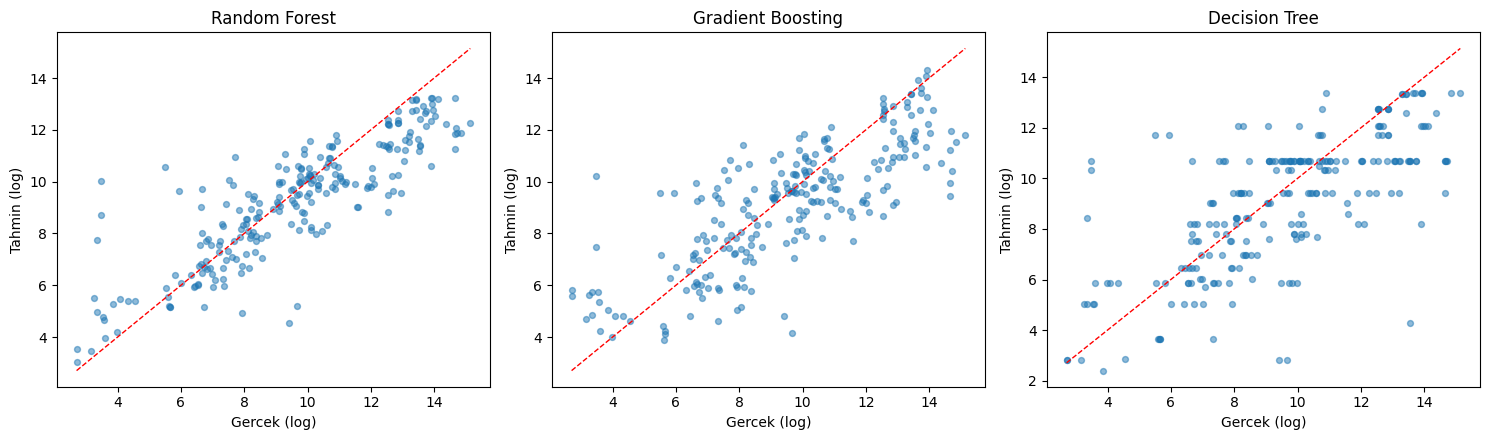

In [9]:
en_iyi_3 = sonuc_df['Model'].head(3).tolist()
print(en_iyi_3)

fig, eksenler = plt.subplots(1, 3, figsize=(15, 4.5))
for i, isim in enumerate(en_iyi_3):
    ax = eksenler[i]
    ax.scatter(y_test, tahmin_sozluk[isim], alpha=0.5, s=18)
    sinir = [y_test.min(), y_test.max()]
    ax.plot(sinir, sinir, 'r--', linewidth=1)
    ax.set_title(isim)
    ax.set_xlabel('Gercek (log)')
    ax.set_ylabel('Tahmin (log)')
plt.tight_layout()
plt.savefig('en_iyi3_gercek_vs_tahmin.png')
plt.show()

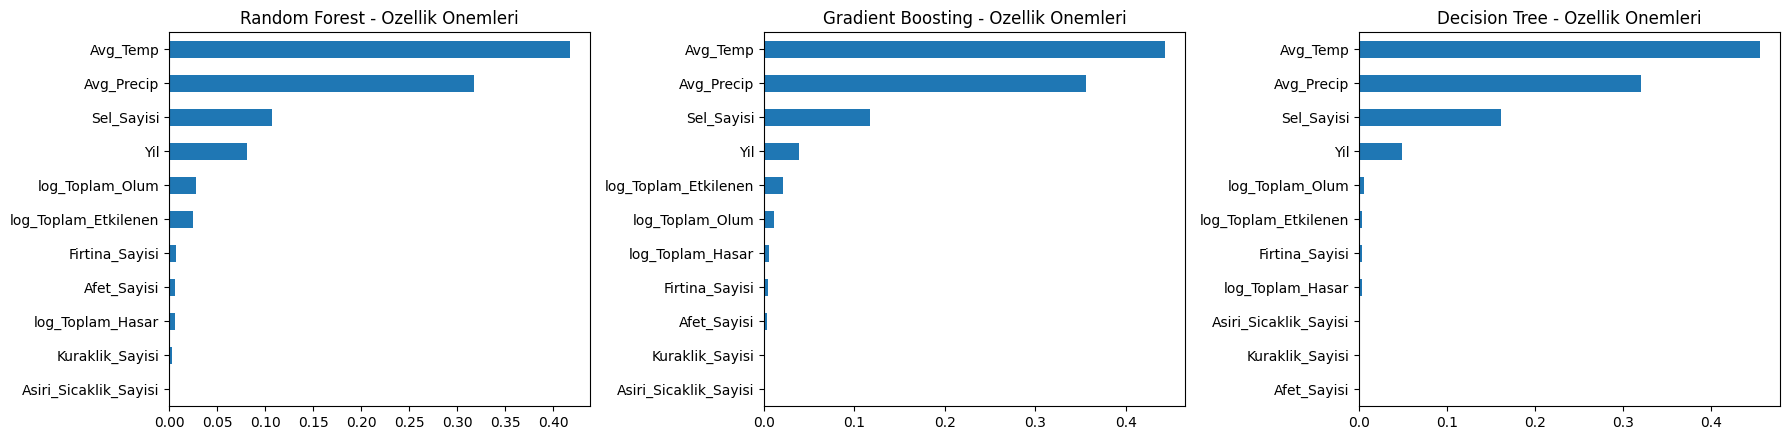

In [10]:
agac_modelleri = {isim: modeller[isim][0] for isim in en_iyi_3 if hasattr(modeller[isim][0], 'feature_importances_')}

fig, eksenler = plt.subplots(1, len(agac_modelleri), figsize=(6*len(agac_modelleri), 4.5))
if len(agac_modelleri) == 1:
    eksenler = [eksenler]
for ax, (isim, model) in zip(eksenler, agac_modelleri.items()):
    onem = pd.Series(model.feature_importances_, index=ozellikler).sort_values()
    onem.plot(kind='barh', ax=ax)
    ax.set_title(f'{isim} - Ozellik Onemleri')
plt.tight_layout()
plt.savefig('en_iyi3_ozellik_onemleri.png')
plt.show()

In [11]:
test_sonuc = X_test.copy()
test_sonuc['Gercek_Kisi'] = np.expm1(y_test.values).round(0)
for isim in en_iyi_3:
    test_sonuc[f'{isim}_Tahmin_Kisi'] = np.expm1(tahmin_sozluk[isim]).round(0)

test_sonuc.to_excel('en_iyi3_test_tahminleri.xlsx', index=False)
sonuc_df.to_excel('model_karsilastirma.xlsx', index=False)

files.download('en_iyi3_test_tahminleri.xlsx')
files.download('model_karsilastirma.xlsx')
files.download('en_iyi3_gercek_vs_tahmin.png')
files.download('en_iyi3_ozellik_onemleri.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>